# Library exploration

In [21]:
%load_ext autoreload
%autoreload 2

import networkx as nx

from cpid.io import AtomicCounterfactual, CausalExpression, CausalQuery
from cpid.lp import OrderFunctionalLPSolver
from cpid.signature import (
    PartialOrderSignature,
    SignatureQueryEvaluator,
    TotalOrderSignature,
)

import pyagrum as gum
import pyagrum.lib.notebook as gnb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## IO

### AtomicCounterfactual

In [22]:
# Standard observational term
obs_term = AtomicCounterfactual(target_var="Y", target_val=1, interventions={})
assert obs_term.target_var == "Y"
assert obs_term.target_val == 1
assert obs_term.interventions == {}
print(obs_term)

# Standard interventional term
cf = AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1, "Z": 0})
assert cf.target_var == "Y"
assert cf.target_val == 1
assert cf.interventions == {"X": 1, "Z": 0}
print(cf)

# L2.5 Term
nested_cf = AtomicCounterfactual(
    target_var="Y", target_val=1, interventions={"X": {"Z": 0}}
)
assert nested_cf.target_var == "Y"
assert nested_cf.target_val == 1
assert nested_cf.interventions == {"X": {"Z": 0}}
assert nested_cf.is_nested()
print(nested_cf)

Y=1
Y_{X=1, Z=0}=1
Y_{X={'Z': 0}}=1


### CausalQuery and CausalExpression

In [23]:
q1 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Y", target_val=1)])
q2 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Y", target_val=0)])
q3 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Z", target_val=1)])
expr = q1 + q2
result = q3 - expr
assert isinstance(result, CausalExpression)
assert result.terms[q1] == -1.0
assert result.terms[q2] == -1.0
assert result.terms[q3] == 1.0

print(q1, q2, q3)
print(expr)
print(result)

P(Y=1) P(Y=0) P(Z=1)
+1 * P(Y=1) +1 * P(Y=0)
-1 * P(Y=1) -1 * P(Y=0) +1 * P(Z=1)


## Signature

### TotalOrderSignature

Good query is compatible with signature: True
Bad query is not compatible with signature: Signature is not compatible: requires a path W -> X but none exists in signature structure
Siganture space: 
[((0,), (0, 0), (0, 0, 0, 0)), ((0,), (0, 0), (0, 0, 0, 1)), ((0,), (0, 0), (0, 0, 1, 0)), ((0,), (0, 0), (0, 0, 1, 1)), ((0,), (0, 0), (0, 1, 0, 0))] 
... 
[((1,), (1, 1), (1, 0, 1, 1)), ((1,), (1, 1), (1, 1, 0, 0)), ((1,), (1, 1), (1, 1, 0, 1)), ((1,), (1, 1), (1, 1, 1, 0)), ((1,), (1, 1), (1, 1, 1, 1))]


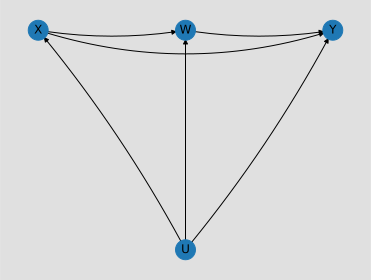

In [24]:
domains = {"X": 2, "W": 2, "Y": 2}
total_order = ["X", "W", "Y"]
sig = TotalOrderSignature(domains, total_order)

# ordered nodes and structure
assert sig.ordered_nodes == ["X", "W", "Y"]
assert sig.structure["X"] == []
assert sig.structure["W"] == ["X"]
assert sig.structure["Y"] == ["X", "W"]

# space size: X -> 2 funcs, W -> 2^(|parents|)=2^2=4 funcs, Y -> 2^(|parents|)=2^2^2=16 funcs => total 128
assert sig.size == 128

TotalOrderSignature.draw_canonical_pscm(sig)

good_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1})
    ]
)

print("Good query is compatible with signature:", sig.is_compatible(good_query))

bad_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="X", target_val=1, interventions={"W": 1})
    ]
)
try:
    sig.is_compatible(bad_query)
except ValueError as e:
    print("Bad query is not compatible with signature:", e)

print(f"Siganture space: \n{sig.space[:5]} \n... \n{sig.space[-5:]}")

### PartialOrderSignature

Identified roots: ['X', 'Z']
Query is (obviously) compatible with signature: True
However, signature has multiple valid topological orderings due to partial order structure.
[['Z', 'X', 'Y'], ['X', 'Z', 'Y']]
<module 'matplotlib.pyplot' from '/Users/eric.rossetto/Documents/Code/conservative_pid/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>


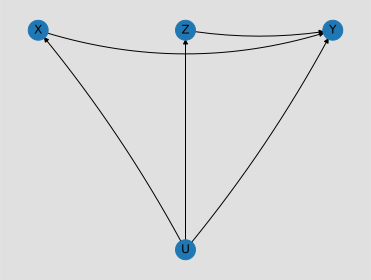

In [25]:
# small example: intervention on X, outcome Y
domains = {"X": 2, "Y": 2, "Z": 2}

q = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"X": 1, "Z": 0}
        )
    ],
    evidence={},
)

sig = PartialOrderSignature(domains, q)

# roots should include X
assert "X" in sig.ordered_nodes
# outcomes should include Y and come after roots
assert sig.ordered_nodes[-1] == "Y"
assert sig.structure["X"] == []
assert sig.structure["Y"] == ["X", "Z"] or sig.structure["Y"] == ["Z", "X"]

print("Query is (obviously) compatible with signature:", sig.is_compatible(q))
print(
    "However, signature has multiple valid topological orderings due to partial order structure."
)
print(list(nx.all_topological_sorts(sig.endogenous_structure())))

print(PartialOrderSignature.draw_canonical_pscm(sig))

## Signature and query evaluation

### TotalOrderSignature

In [26]:
domains = {"X": 2, "W": 2, "Y": 2}
total_order = ["X", "W", "Y"]
sig = TotalOrderSignature(domains, total_order)

p_y1_do_x1w1 = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 1, "X": 1}
        )
    ],
    evidence={},
)

query_eval = SignatureQueryEvaluator(domains, sig, p_y1_do_x1w1)

# Consider row 19
print(f"Signature space size: {len(sig.space)}")
print("Signature space row 19:", sig.space[19])
print(f"Query evaluation for row 19: {query_eval.row_satisfies_query(sig.space[19])}")

Signature space size: 128
Signature space row 19: ((0,), (0, 1), (0, 0, 1, 1))
Query evaluation for row 19: True


### PartialOrderSignature

In [27]:
domains = {"X": 2, "W": 2, "Y": 2}
p_y1_do_x1w1 = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 1, "X": 1}
        )
    ],
    evidence={},
)
sig = PartialOrderSignature(domains, p_y1_do_x1w1)
query_eval = SignatureQueryEvaluator(domains, sig, p_y1_do_x1w1)

print(f"Signature space size: {len(sig.space)}")
print("Signature space row 19:", sig.space[19])
print(f"Query evaluation for row 19: {query_eval.row_satisfies_query(sig.space[19])}")

Identified roots: ['W', 'X']
Signature space size: 64
Signature space row 19: ((0,), (1,), (0, 0, 1, 1))
Query evaluation for row 19: True


## Linear Program with PuLP

### Generate some observational data using `pyagrum`

In [34]:
bn = gum.fastBN("X[2]->W[4]->Y[2]; X->Y")
gum.initRandom(42)
bn.generateCPTs()

df, _ = gum.generateSample(bn, 1000, show_progress=True)

100%|██████████████████████████████████████████████████████|

Log2-Likelihood : -3499.654802885614


### Generate some observational data using `pgmpy`

In [ ]:
# TO ADD

### Generate the data using PPL

### Solving

In [70]:
l1_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="X", target_val=0),
        AtomicCounterfactual(target_var="Y", target_val=1),
    ],
    evidence={"W": 1},
)

l2_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1})
    ],
    evidence={"W": 0},
)

l2_5_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": {"X": 1}}
        )
    ]
)

l3_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1}),
        AtomicCounterfactual(target_var="Y", target_val=0, interventions={"X": 0}),
    ]
)

solver = OrderFunctionalLPSolver(
    data=df,
    # order=["X", "W", "Y"],
    query=l3_query,
    solver_verbose=False,
)
solver

Inferred variable order from query: ['X', 'Y']
Identified roots: ['X']


OrderFunctionalLPSolver:
    Signature: PartialOrderSignature with order ['X', 'Y'] and 8 functions and query: P(Y_{X=1}=1, Y_{X=0}=0)
    Domains: {'W': 4, 'Y': 2, 'X': 2}
    Data distribution: {(0, 1): 0.328, (1, 0): 0.256, (1, 1): 0.212, (0, 0): 0.204}

In [71]:
(lb, ub), probs = solver(return_lp=True)

In [72]:
lb, ub

(0.0, 0.416)

### Exp 1: 3 variable model

- Query $P(A_{X=0}=1, B_{X=1}=0)$
- 2 possible orders $[X, A, B]$ and $[X, B, A]$

In [8]:
domains = {"X": 2, "A": 3, "B": 3}

q = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="A", target_val=1, interventions={"X": 0}),
        AtomicCounterfactual(target_var="B", target_val=0, interventions={"X": 1}),
    ],
    evidence={},
)
# sig = PartialOrderSignature(domains={"X": 2, "A": 2, "B": 2}, query=q)
sig1 = TotalOrderSignature(domains=domains, total_order=["X", "A", "B"])
print("Signature 1 (X -> A -> B):")
print("Structural relations:", sig1.structure)
print("Signature space size:", sig1.size)
sig2 = TotalOrderSignature(domains=domains, total_order=["X", "B", "A"])
print("Signature 2 (X -> B -> A):")
print("Structural relations:", sig2.structure)
print("Signature space size:", sig2.size)

# TotalOrderSignature.draw_canonical_pscm(sig1), TotalOrderSignature.draw_canonical_pscm(sig2)

Signature 1 (X -> A -> B):
Structural relations: {'X': [], 'A': ['X'], 'B': ['X', 'A']}
Signature space size: 13122
Signature 2 (X -> B -> A):
Structural relations: {'X': [], 'B': ['X'], 'A': ['X', 'B']}
Signature space size: 13122


Simulate some skewed data through a BN. We assume that $P(X=0)=0.5$, $P(A=0\mid X=x) = [0.7, 0.2]$, $P(A=1\mid X=x) = [0.2, 0.6]$ and $P(B=0\mid X=x) = [0.2, 0.1]$, $P(B=1\mid X=x) = [0.2, 0.5]$.

In [ ]:
from pgmpy.factors.discrete import TabularCPD
from pgmpy.models import DiscreteBayesianNetwork

model = DiscreteBayesianNetwork([("X", "A"), ("X", "B")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.5], [0.5]])
cpd_a = TabularCPD(
    variable="A",
    variable_card=domains["A"],
    values=[[0.7, 0.3], [0.2, 0.6], [0.1, 0.1]],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_b = TabularCPD(
    variable="B",
    variable_card=domains["B"],
    values=[[0.2, 0.1], [0.2, 0.5], [0.6, 0.4]],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
model.add_cpds(cpd_x, cpd_a, cpd_b)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "A", "B"]).size().reset_index(name="count").iterrows():
    x_val, a_val, b_val, count = row["X"], row["A"], row["B"], row["count"]
    obs_dist[(x_val, a_val, b_val)] = count / len(df)

# sig1 X A B
solver = OrderFunctionalLPSolver({"X": 2, "A": 2, "B": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(q, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 X B A
solver = OrderFunctionalLPSolver({"X": 2, "A": 2, "B": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(q, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'A': ['X'], 'B': ['X', 'A']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.6330000000000001
Structure: {'X': [], 'B': ['X'], 'A': ['X', 'B']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.732


Let's now try a model whose explictly staes $B \to A$.

In [ ]:
model = DiscreteBayesianNetwork([("X", "A"), ("X", "B"), ("A", "B")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.5], [0.5]])
cpd_a = TabularCPD(
    variable="A",
    variable_card=domains["A"],
    values=[[0.7, 0.3], [0.2, 0.6], [0.1, 0.1]],
    evidence=["X"],
    evidence_card=[domains["X"]],
)

cpd_b = TabularCPD(
    variable="B",
    variable_card=domains["B"],
    values=[
        [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        [0.2, 0.3, 0.4, 0.5, 0.4, 0.2],
        [0.7, 0.5, 0.3, 0.1, 0.1, 0.2],
    ],
    evidence=["X", "A"],
    evidence_card=[domains["X"], domains["A"]],
)
model.add_cpds(cpd_x, cpd_a, cpd_b)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "A", "B"]).size().reset_index(name="count").iterrows():
    x_val, a_val, b_val, count = row["X"], row["A"], row["B"], row["count"]
    obs_dist[(x_val, a_val, b_val)] = count / len(df)

# sig1 X A B
solver = OrderFunctionalLPSolver({"X": 2, "A": 2, "B": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(q, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 X B A
solver = OrderFunctionalLPSolver({"X": 2, "A": 2, "B": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(q, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'A': ['X'], 'B': ['X', 'A']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.7060000000000001
Structure: {'X': [], 'B': ['X'], 'A': ['X', 'B']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.6779999999999999


Uniform data shows that there is no difference in the bounds obtained and this is expected since the query $P(A_{X=0}=1, B_{X=1}=0)$ does not know if either $A \to B$ or $B \to A$ holds true.

In [ ]:
# Generate some uniform data
obs_dist_uniform = {}
for x in [0, 1]:
    for a in [0, 1]:
        for b in [0, 1]:
            obs_dist_uniform[(x, a, b)] = 1 / 8

# sig1 X A B
solver = OrderFunctionalLPSolver(domains, obs_dist=obs_dist_uniform)
lb, ub = solver.compute_bounds(q, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 X B A
solver = OrderFunctionalLPSolver(domains, obs_dist=obs_dist_uniform)
lb, ub = solver.compute_bounds(q, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

Structure: {'X': [], 'A': ['X'], 'B': ['X', 'A']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.5
Structure: {'X': [], 'B': ['X'], 'A': ['X', 'B']}
Signature size: 13,122 variables
Lower bound: 0.0, Upper bound: 0.5


### Exp 2: CDE

Let's try another query, i.e., $\mathrm{CDE}^{w}_{x_0,x_1} = P(y_{x_0,w}) - P(y_{x_0,w})$. Order of variables can be either $\sigma_1 = [X, W, Y]$ or $\sigma_2 = [W, X, Y]$.

In [12]:
domains = {"X": 2, "W": 4, "Y": 2}

cde_w2_first_term = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 2, "X": 1}
        )
    ],
    evidence={},
)

cde_w2_second_term = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 2, "X": 0}
        )
    ],
    evidence={},
)

query = cde_w2_first_term - cde_w2_second_term

sig1 = TotalOrderSignature(domains=domains, total_order=["X", "W", "Y"])
print("Signature 1 (X -> W -> Y):")
print("Structural relations:", sig1.structure)
print("Signature space size:", sig1.size)
sig2 = TotalOrderSignature(domains=domains, total_order=["W", "X", "Y"])
print("Signature 2 (W -> X -> Y):")
print("Structural relations:", sig2.structure)
print("Signature space size:", sig2.size)

Signature 1 (X -> W -> Y):
Structural relations: {'X': [], 'W': ['X'], 'Y': ['X', 'W']}
Signature space size: 8192
Signature 2 (W -> X -> Y):
Structural relations: {'W': [], 'X': ['W'], 'Y': ['W', 'X']}
Signature space size: 16384


In order to simulate the data we assume first a fully mediated model, that is $X \to W \to Y$.

In [ ]:
model = DiscreteBayesianNetwork([("X", "W"), ("W", "Y")])

cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],
        [0.2, 0.3],
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[[0.6, 0.65, 0.8, 0.5], [0.4, 0.35, 0.2, 0.5]],
    evidence=["W"],
    evidence_card=[domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "W", "Y"]).size().reset_index(name="count").iterrows():
    x_val, w_val, y_val, count = row["X"], row["W"], row["Y"], row["count"]
    obs_dist[(x_val, w_val, y_val)] = count / len(df)

# sig1 X W Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 W X Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# absurd signature with Y as root, this fails
sig3 = TotalOrderSignature(domains=domains, total_order=["Y", "X", "W"])
print("Signature 3 (Y -> X -> W):")
print("Structural relations:", sig3.structure)
print("Signature space size:", sig3.size)
solver = OrderFunctionalLPSolver(
    {"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist, solver_verbose=True
)
lb, ub = solver.compute_bounds(query, sig3)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'W': ['X'], 'Y': ['X', 'W']}
Signature size: 8,192 variables
Lower bound: -0.8760000000000001, Upper bound: 0.936
Structure: {'W': [], 'X': ['W'], 'Y': ['W', 'X']}
Signature size: 16,384 variables
Lower bound: -0.3819999999999999, Upper bound: 0.382
Signature 3 (Y -> X -> W):
Structural relations: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature space size: 2048
Structure: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature size: 2,048 variables
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/eric.rossetto/Documents/Code/conservative_pid/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/8n/512vwtk55vl9t7cpnsccvbh40000gp/T/6802a06062c94005a1c39f0e4b5636da-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8n/512vwtk55vl9t7cpnsccvbh40000gp/T/6802a06062c94005a1c39f0e4b5636da-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 22

And now simulate the data in partially mediated model where we also add the arc $X \to Y$.

In [ ]:
model = DiscreteBayesianNetwork([("X", "W"), ("X", "Y"), ("W", "Y")])

cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],
        [0.2, 0.3],
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.5, 0.4],
        [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.5, 0.6],
    ],
    evidence=["X", "W"],
    evidence_card=[domains["X"], domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "W", "Y"]).size().reset_index(name="count").iterrows():
    x_val, w_val, y_val, count = row["X"], row["W"], row["Y"], row["count"]
    obs_dist[(x_val, w_val, y_val)] = count / len(df)

# sig1 X W Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 W X Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# absurd signature with Y as root, this fails
sig3 = TotalOrderSignature(domains=domains, total_order=["Y", "X", "W"])
print("Signature 3 (Y -> X -> W):")
print("Structural relations:", sig3.structure)
print("Signature space size:", sig3.size)
solver = OrderFunctionalLPSolver(
    {"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist, solver_verbose=False
)
lb, ub = solver.compute_bounds(query, sig3)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'W': ['X'], 'Y': ['X', 'W']}
Signature size: 8,192 variables
Lower bound: -0.9159999999999999, Upper bound: 0.896
Structure: {'W': [], 'X': ['W'], 'Y': ['W', 'X']}
Signature size: 16,384 variables
Lower bound: -0.3819999999999999, Upper bound: 0.382
Signature 3 (Y -> X -> W):
Structural relations: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature space size: 2048
Structure: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature size: 2,048 variables
Lower bound: None, Upper bound: None


Let's now try some data generating process like $Y \gets X \to W$.

In [ ]:
model = DiscreteBayesianNetwork([("X", "W"), ("X", "Y")])

cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],
        [0.2, 0.3],
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5],
        [0.4, 0.5],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "W", "Y"]).size().reset_index(name="count").iterrows():
    x_val, w_val, y_val, count = row["X"], row["W"], row["Y"], row["count"]
    obs_dist[(x_val, w_val, y_val)] = count / len(df)

# sig1 X W Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 W X Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# absurd signature with Y as root, this fails
sig3 = TotalOrderSignature(domains=domains, total_order=["Y", "X", "W"])
print("Signature 3 (Y -> X -> W):")
print("Structural relations:", sig3.structure)
print("Signature space size:", sig3.size)
solver = OrderFunctionalLPSolver(
    {"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist, solver_verbose=False
)
lb, ub = solver.compute_bounds(query, sig3)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'W': ['X'], 'Y': ['X', 'W']}
Signature size: 8,192 variables
Lower bound: -0.885, Upper bound: 0.927
Structure: {'W': [], 'X': ['W'], 'Y': ['W', 'X']}
Signature size: 16,384 variables
Lower bound: -0.3819999999999999, Upper bound: 0.382
Signature 3 (Y -> X -> W):
Structural relations: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature space size: 2048
Structure: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature size: 2,048 variables
Lower bound: None, Upper bound: None


And finally, $X \to Y \gets W$.

In [ ]:
model = DiscreteBayesianNetwork([("X", "Y"), ("W", "Y")])

cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1],
        [0.2],
        [0.3],
        [0.4],
    ],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.5, 0.4],
        [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.5, 0.6],
    ],
    evidence=["X", "W"],
    evidence_card=[domains["X"], domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)

df = model.simulate(n_samples=1000, seed=42)
obs_dist = {}
for _, row in df.groupby(["X", "W", "Y"]).size().reset_index(name="count").iterrows():
    x_val, w_val, y_val, count = row["X"], row["W"], row["Y"], row["count"]
    obs_dist[(x_val, w_val, y_val)] = count / len(df)

# sig1 X W Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig1)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# sig2 W X Y
solver = OrderFunctionalLPSolver({"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(query, sig2)
print(f"Lower bound: {lb}, Upper bound: {ub}")

# absurd signature with Y as root, this fails
sig3 = TotalOrderSignature(domains=domains, total_order=["Y", "X", "W"])
print("Signature 3 (Y -> X -> W):")
print("Structural relations:", sig3.structure)
print("Signature space size:", sig3.size)
solver = OrderFunctionalLPSolver(
    {"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist, solver_verbose=False
)
lb, ub = solver.compute_bounds(query, sig3)
print(f"Lower bound: {lb}, Upper bound: {ub}")

  0%|          | 0/3 [00:00<?, ?it/s]

Structure: {'X': [], 'W': ['X'], 'Y': ['X', 'W']}
Signature size: 8,192 variables
Lower bound: -0.8720000000000001, Upper bound: 0.8540000000000001
Structure: {'W': [], 'X': ['W'], 'Y': ['W', 'X']}
Signature size: 16,384 variables
Lower bound: -0.29599999999999993, Upper bound: 0.29599999999999993
Signature 3 (Y -> X -> W):
Structural relations: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature space size: 2048
Structure: {'Y': [], 'X': ['Y'], 'W': ['Y', 'X']}
Signature size: 2,048 variables
Lower bound: None, Upper bound: None


In [ ]:
import pandas as pd


def _obs_dist_from_model(model, variable_order, n_samples=1000, seed=42):
    sample = model.simulate(n_samples=n_samples, seed=seed)
    grouped = sample.groupby(variable_order).size().reset_index(name="count")
    obs_dist = {}
    for _, row in grouped.iterrows():
        key = tuple(row[var] for var in variable_order)
        obs_dist[key] = row["count"] / len(sample)
    return obs_dist


def _run_bounds_for_scenario(scenario_name, model, variable_order, signatures):
    obs_dist_local = _obs_dist_from_model(model, variable_order)
    rows = []
    for signature_name, signature in signatures.items():
        # Generate the distribution using the signature's specific order
        obs_dist_local = _obs_dist_from_model(model, signature.ordered_nodes)

        solver = OrderFunctionalLPSolver(
            {"X": 2, "W": 4, "Y": 2}, obs_dist=obs_dist_local
        )
        lower_bound, upper_bound = solver.compute_bounds(query, signature)
        rows.append(
            {
                "scenario": scenario_name,
                "signature": signature_name,
                "order": ", ".join(signature.ordered_nodes),
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
            }
        )
    return rows


results = []

sig1 = TotalOrderSignature(domains=domains, total_order=["X", "W", "Y"])
sig2 = TotalOrderSignature(domains=domains, total_order=["W", "X", "Y"])
sig3 = TotalOrderSignature(domains=domains, total_order=["Y", "X", "W"])
sig4 = TotalOrderSignature(domains=domains, total_order=["X", "Y", "W"])
sig5 = TotalOrderSignature(domains=domains, total_order=["W", "Y", "X"])
sig6 = TotalOrderSignature(domains=domains, total_order=["Y", "W", "X"])
signatures = {
    "sig1": sig1,
    "sig2": sig2,
    # "sig3": sig3, # violation
    # "sig4": sig4, # violation
    # "sig5": sig5, # violation, but does not fail
    # "sig6": sig6, # violation
}

# =================================================
# Fully mediated: X -> W -> Y
# =================================================
model = DiscreteBayesianNetwork([("X", "W"), ("W", "Y")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],  # W=0 | X=0, X=1
        [0.2, 0.3],  # W=1 | X=0, X=1
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.65, 0.8, 0.5],  # Y=0 | W=0,1,2,3
        [0.4, 0.35, 0.2, 0.5],  # Y=1 | W=0,1,2,3
    ],
    evidence=["W"],
    evidence_card=[domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)
results.extend(
    _run_bounds_for_scenario("fully_mediated", model, ["X", "W", "Y"], signatures)
)

# =================================================
# Partially mediated: X -> W -> Y and X -> Y
# =================================================
model = DiscreteBayesianNetwork([("X", "W"), ("X", "Y"), ("W", "Y")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],
        [0.2, 0.3],
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.5, 0.4],
        [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.5, 0.6],
    ],
    evidence=["X", "W"],
    evidence_card=[domains["X"], domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)
results.extend(
    _run_bounds_for_scenario("partially_mediated", model, ["X", "W", "Y"], signatures)
)

# =================================================
# Fork: X -> W and X -> Y
# =================================================
model = DiscreteBayesianNetwork([("X", "W"), ("X", "Y")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1, 0.2],
        [0.2, 0.3],
        [0.3, 0.1],
        [0.4, 0.4],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5],
        [0.4, 0.5],
    ],
    evidence=["X"],
    evidence_card=[domains["X"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)
results.extend(_run_bounds_for_scenario("fork", model, ["X", "W", "Y"], signatures))

# =================================================
# Collider: X -> Y <- W
# =================================================
model = DiscreteBayesianNetwork([("X", "Y"), ("W", "Y")])
cpd_x = TabularCPD(variable="X", variable_card=domains["X"], values=[[0.55], [0.45]])
cpd_w = TabularCPD(
    variable="W",
    variable_card=domains["W"],
    values=[
        [0.1],
        [0.2],
        [0.3],
        [0.4],
    ],
)
cpd_y = TabularCPD(
    variable="Y",
    variable_card=domains["Y"],
    values=[
        [0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.5, 0.4],
        [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.5, 0.6],
    ],
    evidence=["X", "W"],
    evidence_card=[domains["X"], domains["W"]],
)
model.add_cpds(cpd_x, cpd_w, cpd_y)
results.extend(_run_bounds_for_scenario("collider", model, ["X", "W", "Y"], signatures))

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["scenario", "signature"])
    .sort_values(["scenario", "signature"])
    .reset_index(drop=True)
)

results_df["query"] = query.__str__()

results_df

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

ValueError: No group keys passed!

In [47]:
sig1 = PartialOrderSignature(domains=domains, query=query)

In [ ]:
domains = {"X": 2, "Y": 2}
sig = TotalOrderSignature(domains=domains, total_order=["X", "Y"])

# Observational joint: (X,Y) ordered as (X,Y)
obs_dist = {
    (0, 0): 0.25,
    (0, 1): 0.25,
    (1, 0): 0.1,
    (1, 1): 0.4,
}

# Empirical conditional P(Y=1 | X=1) = P(X=1,Y=1)/P(X=1) = 0.4 / 0.5 = 0.8
q = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", interventions={"X": 1}, target_val=1)
    ],
    evidence={"X": 1},
)

solver = OrderFunctionalLPSolver(domains, obs_dist=obs_dist)
lb, ub = solver.compute_bounds(q, sig)

Structure: {'X': [], 'Y': ['X']}
Signature size: 8 variables
Evaluating row: {'X': 0, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 0, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 1} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 0} against evidence: {'X': 1}
Evaluating row: {'X': 1, 'Y': 1} agains

In [ ]:
domains = {"X": 2, "W": 2, "Y": 2}
sig = PartialOrderSignature(domains=domains, query=q)

# Observational joint: (X,Y) ordered as (X,Y)
obs_dist = {
    (0, 0, 0): 0.25,
    (0, 0, 1): 0.25,
    (0, 1, 0): 0.1,
    (0, 1, 1): 0.4,
    (1, 0, 0): 0.1,
    (1, 0, 1): 0.1,
    (1, 1, 0): 0.05,
    (1, 1, 1): 0.05,
}

# Marginalise to (X,Y) ordered as (X,Y)
obs_dist_marginal = {}
for w in [0, 1]:
    for x in [0, 1]:
        for y in [0, 1]:
            obs_dist_marginal[(x, y)] = (
                obs_dist_marginal.get((x, y), 0) + obs_dist[(x, w, y)]
            )

# Empirical conditional P(Y=1 | X=1) = P(X=1,Y=1)/P(X=1) = 0.4 / 0.5 = 0.8
q = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", interventions={"X": 1}, target_val=1)
    ],
    evidence={"X": 1},
)

solver = OrderFunctionalLPSolver(domains, obs_dist=obs_dist_marginal)
lb, ub = solver.compute_bounds(q, sig)

Identified roots: ['X']
Structure: {'X': [], 'Y': ['X']}
Signature size: 8 variables


In [ ]:
import itertools

import pandas as pd

from cpid.io import AtomicCounterfactual, CausalQuery
from cpid.lp import OrderFunctionalLPSolver
from cpid.signature import TotalOrderSignature


def get_uniform_obs_dist(ordered_nodes):
    states = list(itertools.product([0, 1], repeat=len(ordered_nodes)))
    prob = 1.0 / len(states)
    return {state: prob for state in states}


def get_correlated_obs_dist(ordered_nodes):
    """
    Generates a distribution where X, Y, and G are highly correlated.
    This forces the LP to structurally explain the correlation either
    via confounding (Root G) or collider bias (Leaf G).
    """
    dist = {}
    for state in itertools.product([0, 1], repeat=len(ordered_nodes)):
        state_dict = dict(zip(ordered_nodes, state))
        # Assign high probability when all variables share the same state
        if state_dict["G"] == state_dict["X"] and state_dict["X"] == state_dict["Y"]:
            dist[state] = 0.35
        else:
            # Distribute the remaining 0.30 mass across the 6 other states
            dist[state] = 0.30 / 6.0
    return dist


def main():
    domains = {"X": 2, "Y": 2, "G": 2}

    # Query: P(Y_{X=1}=1 | G=1)
    query = CausalQuery(
        counterfactuals=[AtomicCounterfactual("Y", 1, {"X": 1})], evidence={"G": 1}
    )

    # Case A: G as a Universal Root (Exogenous Confounder)
    sig_root = TotalOrderSignature(domains, ["G", "X", "Y"])

    # Case B: G as a Universal Leaf (Downstream Collider)
    sig_leaf = TotalOrderSignature(domains, ["X", "Y", "G"])

    # Case C: G as a Mediator (X -> G -> Y) - This is not an extreme but serves as a sanity check
    sig_mediator = TotalOrderSignature(domains, ["X", "G", "Y"])

    signatures = {
        "G_as_Root (Confounder)": sig_root,
        "G_as_Leaf (Collider)  ": sig_leaf,
        "G_as_Mediator        ": sig_mediator,
    }

    results = []

    for sig_name, signature in signatures.items():
        obs_dist = get_correlated_obs_dist(signature.ordered_nodes)

        solver = OrderFunctionalLPSolver(
            domains, obs_dist=obs_dist, solver_verbose=False
        )
        lower, upper = solver.compute_bounds(query, signature)

        results.append(
            {
                "Topology": sig_name.strip(),
                "Canonical Order": " -> ".join(signature.ordered_nodes),
                "Lower Bound": round(lower, 4),
                "Upper Bound": round(upper, 4),
            }
        )

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))


if __name__ == "__main__":
    main()

Structure: {'G': [], 'X': ['G'], 'Y': ['G', 'X']}
Signature size: 128 variables


NameError: name 'evidence_query' is not defined

In [ ]:
from abc import ABC, abstractmethod
from typing import Dict, Tuple

import pulp

from cpid.io import CausalExpression, CausalQuery
from cpid.signature import (
    ResponseSignature,
    SignatureQueryEvaluator,
    TotalOrderSignature,
)


class CausalLP:
    def __init__(
        self,
        domains: dict[str, int],
        obs_dist: dict[tuple[int], float],
        solver_verbose: bool = False,
    ):
        self.domains = domains
        self.obs_dist = obs_dist
        self.solver_verbose = solver_verbose

    def compute_bounds(self, query, signature_obj: ResponseSignature, return_lp=False):
        eq_classes = signature_obj.get_equivalence_classes(query)
        bounds = []
        pulp_probs = []

        for sense in [pulp.LpMinimize, pulp.LpMaximize]:
            prob = pulp.LpProblem("Bounds", sense)

            # Variables allocated strictly for unique algebraic footprints
            y_vars = pulp.LpVariable.dicts("y_quot", eq_classes.keys(), lowBound=0)
            t = pulp.LpVariable("t", lowBound=0)

            # Simplex constraint via Charnes-Cooper
            prob += pulp.lpSum(y_vars.values()) - t == 0

            # Observational Constraints
            for obs_val, obs_prob in self.obs_dist.items():
                matching_vars = [
                    y_vars[k] for k in eq_classes.keys() if k[0] == obs_val
                ]
                prob += pulp.lpSum(matching_vars) - (obs_prob * t) == 0

            # Denominator constraint (d^T y = 1)
            denom_vars = [y_vars[k] for k in eq_classes.keys() if k[2] == 1.0]
            if denom_vars:
                prob += pulp.lpSum(denom_vars) == 1.0
            else:
                # Unconditional query fallback
                prob += t == 1.0

            # Objective Function (c^T y)
            obj_terms = [k[1] * y_vars[k] for k in eq_classes.keys() if k[1] != 0.0]
            prob += pulp.lpSum(obj_terms)

            prob.solve(pulp.PULP_CBC_CMD(msg=self.solver_verbose))
            bounds.append(pulp.value(prob.objective))
            pulp_probs.append(prob)

        if return_lp:
            return tuple(bounds), tuple(pulp_probs)

        return tuple(bounds)

In [22]:
domains = {"X": 2, "W": 4, "Y": 2}
sig = TotalOrderSignature(domains=domains, total_order=["X", "Y"])

In [ ]:
from cpid.io import AtomicCounterfactual, CausalQuery

sig.get_equivalence_classes(
    CausalQuery(
        counterfactuals=[
            AtomicCounterfactual(
                target_var="Y", target_val=1, interventions={"W": 2, "X": 1}
            )
        ],
        evidence={},
    )
)

{((0, 0), 0.0, 1.0): 1,
 ((0, 0), 1.0, 1.0): 1,
 ((0, 1), 0.0, 1.0): 1,
 ((0, 1), 1.0, 1.0): 1,
 ((1, 0), 0.0, 1.0): 2,
 ((1, 1), 1.0, 1.0): 2}

In [ ]:
solver = OrderFunctionalLPSolver(
    domains={"X": 2, "Y": 2},
    obs_dist={
        (0, 0): 0.25,
        (0, 1): 0.25,
        (1, 0): 0.1,
        (1, 1): 0.4,
    },
    solver_verbose=True,
)
(lb, ub), (lb_prob, ub_prob) = solver.compute_bounds(
    CausalQuery(
        counterfactuals=[
            AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1})
        ],
    ),
    sig,
    return_lp=True,
)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/eric.rossetto/Documents/Code/conservative_pid/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/8n/512vwtk55vl9t7cpnsccvbh40000gp/T/b394f59d7477488ca4d6db47a08f9475-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8n/512vwtk55vl9t7cpnsccvbh40000gp/T/b394f59d7477488ca4d6db47a08f9475-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 11 COLUMNS
At line 38 RHS
At line 45 BOUNDS
At line 46 ENDATA
Problem MODEL has 6 rows, 7 columns and 23 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-6) rows, 0 (-7) columns and 0 (-23) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 0.4
After Postsolve, objective 0.4, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 0.4 - 0 iterations time 0.002, Presolve 0.0

In [31]:
lb_prob

Bounds:
MINIMIZE
1.0*y_quot_((0,_0),_1.0,_1.0) + 1.0*y_quot_((0,_1),_1.0,_1.0) + 1.0*y_quot_((1,_1),_1.0,_1.0) + 0.0
SUBJECT TO
_C1: - t + y_quot_((0,_0),_0.0,_1.0) + y_quot_((0,_0),_1.0,_1.0)
 + y_quot_((0,_1),_0.0,_1.0) + y_quot_((0,_1),_1.0,_1.0)
 + y_quot_((1,_0),_0.0,_1.0) + y_quot_((1,_1),_1.0,_1.0) = 0

_C2: - 0.25 t + y_quot_((0,_0),_0.0,_1.0) + y_quot_((0,_0),_1.0,_1.0) = 0

_C3: - 0.25 t + y_quot_((0,_1),_0.0,_1.0) + y_quot_((0,_1),_1.0,_1.0) = 0

_C4: - 0.1 t + y_quot_((1,_0),_0.0,_1.0) = 0

_C5: - 0.4 t + y_quot_((1,_1),_1.0,_1.0) = 0

_C6: y_quot_((0,_0),_0.0,_1.0) + y_quot_((0,_0),_1.0,_1.0)
 + y_quot_((0,_1),_0.0,_1.0) + y_quot_((0,_1),_1.0,_1.0)
 + y_quot_((1,_0),_0.0,_1.0) + y_quot_((1,_1),_1.0,_1.0) = 1

VARIABLES
t Continuous
y_quot_((0,_0),_0.0,_1.0) Continuous
y_quot_((0,_0),_1.0,_1.0) Continuous
y_quot_((0,_1),_0.0,_1.0) Continuous
y_quot_((0,_1),_1.0,_1.0) Continuous
y_quot_((1,_0),_0.0,_1.0) Continuous
y_quot_((1,_1),_1.0,_1.0) Continuous